Customer churn is a common issue in the telecommunications industry. When a customer leaves, the impact is not only the loss of future revenue, but also the additional cost required to acquire a new customer as a replacement.

From a cost perspective, retaining existing customers is generally much cheaper than acquiring new ones. In this scenario, we assume:
- The retention cost per at-risk customer is 100,000
- The estimated loss from one churned customer is 1,000,000

With this gap between retention cost and potential loss, the company has a strong incentive to act early — as long as high-risk customers can be identified with reasonable accuracy.<br>
In practical terms, the business needs a way to flag customers who are likely to churn, so retention efforts can be focused where they are financially justified.<br>
This project addresses that need by developing a predictive model to help prioritize customers for retention treatment.

---
### Project Objectives

In this project, the goals are fairly straightforward:

1. Build a model that can estimate how likely each customer is to churn
2. Use those predictions to decide which customers should be prioritized for retention efforts
3. Make sure the retention budget is spent where it gives the biggest financial return

In [ ]:
import os
import pandas as pd

path_this = os.path.dirname(os.path.abspath(__name__))
path_root = os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

### From Business Problem to Analytical Approach

The aim here isn’t just to predict churn for the sake of accuracy. The real goal is to support better retention decisions, especially when budget and resources are limited.

Using the earlier assumptions:

* Retaining one at-risk customer costs **100,000**
* Losing one customer results in an estimated loss of **1,000,000**

This creates a clear trade-off:

* If we target a customer who wouldn’t have churned, we waste retention budget
* If we **miss a customer who does churn**, the company takes a **much bigger financial hit**

So the problem becomes more than a classification task. It turns into a decision problem:

> How can we use customer data to find people whose risk of churn is high enough that intervening is financially worth it?

This framing guides how the model will be built and how its predictions will eventually be used.

---

### How the Problem is Framed Analytically
In this project, churn prediction is not treated as a standard classification task, but as a decision-making problem with financial consequences.

Instead of only predicting whether a customer will churn, the model estimates the probability of churn for each customer. That probability is then used to approximate the potential financial risk if no action is taken:
```math
Expected Loss = 𝑃(churn) × 1,000,000
```
This value is compared against the retention cost (100,000).
If the expected loss is higher than the cost of intervention, the customer is considered a reasonable target for retention efforts.

With this setup, the modeling task is aligned with how the business actually makes decisions — not just who is likely to churn, but where retention spending makes financial sense.

### 📊 Dataset Overview

The dataset contains 7,032 customer records, where each row represents an individual customer of a telecommunications company. The target variable, ```Churn```, indicates whether a customer has stopped using the service.

The target distribution shows a moderate class imbalance:  
- Churn: 26.58% (1,869 customers)
- Not Churn: 73.42% (5,163 customers)

This imbalance is important to consider during modeling and evaluation, as predicting all customers as non-churn would still yield relatively high accuracy but no real business value.

The dataset includes 17 features describing different aspects of customer behavior and characteristics. These features can be broadly grouped into:
- Customer demographic and profile information (e.g., gender, senior citizen status, presence of partner or dependents, tenure)
- Service subscription details (e.g., type of internet service and additional service features)
- Contract and account information (e.g., contract type, length of subscription)
- Billing and payment information (e.g., monthly charges, total charges, payment method)

The features consist of a mix of numerical and categorical variables, which require appropriate preprocessing before being used in a Logistic Regression model.

For model development and performance evaluation, the dataset will be split into training and testing sets using an 80:20 ratio. **As a baseline approach**, feature selection will be **handled automatically through L1 regularization (Lasso)** within the Logistic Regression model, allowing the model to retain only the most relevant predictors.

#### Load Dataset

In [ ]:
df_dataset = pd.read_csv(os.path.join(path_dataset,'preprocessed_dataset.csv'))
demograph_features = ['gender', 'SeniorCitizen', 'Partner', 'Dependents']
services_features = [
	'PhoneService', 'MultipleLines', 'InternetService', 
	'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 
	'TechSupport', 'StreamingTV', 'StreamingMovies']
membership_features = [
	'Contract', 'PaperlessBilling', 'PaymentMethod', 
	'MonthlyCharges', 'TotalCharges', 'tenure', 'Churn']

display(df_dataset.loc[
	:, ['customerID'] + demograph_features + ['Churn']].sample(5, random_state=42))
display(df_dataset.loc[
	:, ['customerID'] + services_features + ['Churn']].sample(5, random_state=42))
display(df_dataset.loc[
	:, ['customerID'] + membership_features + ['Churn']].sample(5, random_state=42))

,customerID,gender,SeniorCitizen,Partner,Dependents,Churn
2476,6614-ywysc,male,yes,yes,no,0
6773,9546-kdtrb,female,no,no,no,0
6116,0871-uruwo,male,no,yes,no,1
3047,5151-hqrdg,male,no,yes,no,0
4092,6624-jdrds,female,no,no,no,0


,customerID,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Churn
2476,6614-ywysc,yes,yes,no,no internet service,no internet service,no internet service,no internet service,no internet service,no internet service,0
6773,9546-kdtrb,yes,yes,no,no internet service,no internet service,no internet service,no internet service,no internet service,no internet service,0
6116,0871-uruwo,yes,yes,fiber optic,no,no,yes,no,yes,yes,1
3047,5151-hqrdg,yes,yes,dsl,yes,no,no,no,no,no,0
4092,6624-jdrds,no,no phone service,dsl,yes,no,no,no,no,no,0


,customerID,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,tenure,Churn,Churn
2476,6614-ywysc,two year,no,bank transfer (automatic),25.00,1501.75,61,0,0
6773,9546-kdtrb,month-to-month,no,bank transfer (automatic),24.70,465.85,19,0,0
6116,0871-uruwo,month-to-month,yes,credit card (automatic),102.25,1359.00,13,1,1
3047,5151-hqrdg,month-to-month,yes,mailed check,55.05,2030.75,37,0,0
4092,6624-jdrds,month-to-month,no,bank transfer (automatic),29.45,161.45,6,0,0


### Modeling
At this stage, the dataset is already cleaned and structured, and the business objective has been clearly defined. The next step is to translate this setup into a modeling pipeline.

Since the goal is to estimate churn probability while keeping the model interpretable and suitable as a baseline, Logistic Regression is used as the starting point. This model is particularly useful here because its outputs can be directly interpreted as probabilities, which align well with the cost-based decision framework defined earlier.

Before training the model, several preprocessing steps are required to ensure the data is in the right format for Logistic Regression. These steps include handling categorical variables, scaling numerical features, and splitting the data into training and testing sets. To keep the workflow reproducible and avoid data leakage, these steps will be implemented inside a modeling pipeline.

We start by preparing the feature matrix and target variable.

In [2]:
import os
import sys

from copy import deepcopy
from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler, OneHotEncoder, LabelBinarizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

In [3]:
path_this = os.path.dirname(os.path.abspath(__name__))
path_root = os.path.join(path_this, '..')
path_dataset = os.path.join(path_root, 'data')

# Dataset Preparation & Preprocessing

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


# Standardizing Data

In [142]:
def preprocess_churn_col(value:str):
	if isinstance(value, int):
		return value
	elif value.lower() == 'yes':
		return 1
	elif value.lower() == 'no':
		return 0

In [143]:
df_dataset['TotalCharges'] = pd.to_numeric(df_dataset['TotalCharges'], errors='coerce')
df_dataset['Churn'] = df_dataset['Churn'].map(preprocess_churn_col)

In [144]:
df_dataset = df_dataset.loc[df_dataset['tenure'] != 0].reset_index(drop=True)
df_dataset.isna().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Logistic Regression Model

In [145]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
	accuracy_score, recall_score, precision_score, f1_score, confusion_matrix,
	classification_report, roc_auc_score, log_loss, RocCurveDisplay)

scaler = StandardScaler()

In [146]:
df_logreg = deepcopy(df_dataset)
df_logreg = df_logreg.dropna()

In [147]:
df_logreg.loc[df_logreg['Churn'] == 1].value_counts(
	subset=['InternetService', 'PhoneService'], normalize=True).reset_index()

,InternetService,PhoneService,proportion
0,Fiber optic,Yes,0.693954
1,DSL,Yes,0.154628
2,DSL,No,0.090958
3,No,Yes,0.060460


In [148]:
df_logreg.loc[
	(df_logreg['InternetService'] == 'Fiber optic') & 
	(df_logreg['PhoneService'] == 'No')
]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [149]:
# df_logreg['PhoneService'].value_counts(dropna=False)
df_logreg.loc[
	df_logreg['PhoneService'] == 'Yes', 'InternetService'].value_counts()

InternetService
Fiber optic    3096
DSL            1736
No             1520
Name: count, dtype: int64

In [150]:
TARGET_COL = 'Churn'
X = df_logreg.drop(
	columns=[
		TARGET_COL, 'customerID', 'TotalCharges', 'tenure']) #'PhoneService', 'InternetService', 
		# 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
		# 'MultipleLines', 'StreamingTV', 'StreamingMovies', 'tenure',
		# , 'tenure', 'PaperlessBilling', 'PaymentMethod', 
		# also drop demography features
		# 'gender', 'SeniorCitizen', 'Partner', 'Dependents']) #
y = df_logreg[TARGET_COL]

In [171]:
df_logreg.Churn.value_counts(normalize=True).mul(100)

Churn
0    73.421502
1    26.578498
Name: proportion, dtype: float64

In [152]:
X_train, X_test, y_train, y_test = train_test_split(
	X, y, test_size=0.2, random_state=42, stratify=y)

In [153]:
numerical_features = X.select_dtypes(exclude='object').columns.to_list()
categorical_features = X.select_dtypes(include='object').columns.to_list()

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), numerical_features),
        ("cat", OneHotEncoder(drop="first", handle_unknown="ignore"), categorical_features)
    ]
)

In [154]:
log_reg = LogisticRegression(
    l1_ratio=0,
    solver="lbfgs",
	# class_weight=None,
    # solver="liblinear",
    max_iter=1000
)

base_pipeline = Pipeline(
    steps=[
        ("preprocessing", preprocessor),
        ("model", log_reg)
    ]
)

base_pipeline.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocessing', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different transformers c

In [155]:
y_proba = base_pipeline.predict_proba(X_test)[:, 1]
y_pred = base_pipeline.predict(X_test)
# y_pred = (y_proba >= 0.35).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7789623312011372
Precision: 0.5969230769230769
Recall: 0.5187165775401069
F1 Score: 0.5550786838340487
ROC AUC: 0.8126543321720134
Log Loss: 0.4509146323498342

Confusion Matrix:
 [[902 131]
 [180 194]]

Classification Report:
               precision    recall  f1-score   support

           0       0.83      0.87      0.85      1033
           1       0.60      0.52      0.56       374

    accuracy                           0.78      1407
   macro avg       0.72      0.70      0.70      1407
weighted avg       0.77      0.78      0.77      1407



In [156]:
import numpy as np

thresholds = np.linspace(0.1, 0.5, 50)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

best_t, best_f1

(np.float64(0.4102040816326531), 0.6044226044226044)

In [157]:
y_proba = base_pipeline.predict_proba(X_test)[:, 1]
# y_pred = base_pipeline.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7711442786069652
Precision: 0.5590909090909091
Recall: 0.6577540106951871
F1 Score: 0.6044226044226044
ROC AUC: 0.8126543321720134
Log Loss: 0.4509146323498342

Confusion Matrix:
 [[839 194]
 [128 246]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.81      0.84      1033
           1       0.56      0.66      0.60       374

    accuracy                           0.77      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.79      0.77      0.78      1407



## Find the best param

In [158]:
from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "model__C": [0.01, 0.1, 1, 2, 3, 4, 5, 10, 100],
    "model__l1_ratio": [0, 1],
    "model__class_weight": [None, "balanced"],
	# "model__max_iter": [500, 1000, 1500, 2000],
    "model__solver": ["liblinear", "lbfgs"]  # needed for l1
}

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)
grid_search = GridSearchCV(
    base_pipeline,
    param_grid,
    scoring="neg_log_loss",
    cv=skf, #5
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


c:\Users\VICTUS\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py:490: FitFailedWarning: 
90 fits failed out of a total of 360.
The score on these train-test partitions for these parameters will be set to nan.
If these failures are not expected, you can try to debug them by setting error_score='raise'.

Below are more details about the failures:
--------------------------------------------------------------------------------
90 fits failed with the following error:
Traceback (most recent call last):
  File "c:\Users\VICTUS\miniconda3\Lib\site-packages\sklearn\model_selection\_validation.py", line 833, in _fit_and_score
    estimator.fit(X_train, y_train, **fit_params)
    ~~~~~~~~~~~~~^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "c:\Users\VICTUS\miniconda3\Lib\site-packages\sklearn\base.py", line 1336, in wrapper
    return fit_method(estimator, *args, **kwargs)
  File "c:\Users\VICTUS\miniconda3\Lib\site-packages\sklearn\pipeline.py", line 621, in fit
    self._final_esti

,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 1], 'model__solver': ['liblinear', 'lbfgs']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more message

In [159]:
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)

Best parameters: {'model__C': 100, 'model__class_weight': None, 'model__l1_ratio': 0, 'model__solver': 'liblinear'}


In [160]:
y_proba = best_model.predict_proba(X_test)[:, 1]
# y_pred = base_pipeline.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7633262260127932
Precision: 0.54627539503386
Recall: 0.6470588235294118
F1 Score: 0.5924112607099143
ROC AUC: 0.8117302804251155
Log Loss: 0.4521059201070705

Confusion Matrix:
 [[832 201]
 [132 242]]

Classification Report:
               precision    recall  f1-score   support

           0       0.86      0.81      0.83      1033
           1       0.55      0.65      0.59       374

    accuracy                           0.76      1407
   macro avg       0.70      0.73      0.71      1407
weighted avg       0.78      0.76      0.77      1407



In [161]:
best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

best_t, best_f1

(np.float64(0.40204081632653066), 0.6021765417170496)

In [162]:
from sklearn.calibration import CalibratedClassifierCV

calibrated_model = CalibratedClassifierCV(
    best_model,
    method="sigmoid",  # or "sigmoid" if data is small
    cv=5
)

calibrated_model.fit(X_train, y_train)

,"estimator estimator: estimator instance, default=NoneThe classifier whose output need to be calibrated to provide moreaccurate `predict_proba` outputs. The default classifier isa :class:`~sklearn.svm.LinearSVC`... versionadded:: 1.2",Pipeline(step...liblinear'))])
,"method method: {'sigmoid', 'isotonic', 'temperature'}, default='sigmoid'The method to use for calibration. Can be:- 'sigmoid', which corresponds to Platt's method (i.e. a binary logistic regression model).- 'isotonic', which is a non-parametric approach.- 'temperature', temperature scaling.Sigmoid and isotonic calibration methods natively support only binaryclassifiers and extend to multi-class classification using a One-vs-Rest (OvR)strategy with post-hoc renormalization, i.e., adjusting the probabilities aftercalibration to ensure they sum up to 1.In contrast, temperature scaling naturally supports multi-class calibration byapplying `softmax(classifier_logits/T)` with a value of `T` (temperature)that optimizes the log loss.For very uncalibrated classifiers on very imbalanced datasets, sigmoidcalibration might be preferred because it fits an additional interceptparameter. This helps shift decision boundaries appropriately when theclassifier being calibrated is biased towards the majority class.Isotonic calibration is not recommended when the number of calibration samplesis too low ``(≪1000)`` since it then tends to overfit... versionchanged:: 1.8 Added option 'temperature'.",'sigmoid'
,"cv cv: int, cross-validation generator, or iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross-validation,- integer, to specify the number of folds.- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if ``y`` is binary or multiclass,:class:`~sklearn.model_selection.StratifiedKFold` is used. If ``y`` isneither binary nor multiclass, :class:`~sklearn.model_selection.KFold`is used.Refer to the :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",5
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors.Base estimator clones are fitted in parallel across cross-validationiterations.See :term:`Glossary ` for more details... versionadded:: 0.24",None
,"ensemble ensemble: bool, or ""auto"", default=""auto""Determines how the calibrator is fitted.""auto"" will use `False` if the `estimator` is a:class:`~sklearn.frozen.FrozenEstimator`, and `True` otherwise.If `True`, the `estimator` is fitted using training data, andcalibrated using testing data, for each `cv` fold. The final estimatoris an ensemble of `n_cv` fitted classifier and calibrator pairs, where`n_cv` is the number of cross-validation folds. The output is theaverage predicted probabilities of all pairs.If `False`, `cv` is used to compute unbiased predictions, via:func:`~sklearn.model_selection.cross_val_predict`, which are thenused for calibration. At prediction time, the classifier used is the`estimator` trained on all the data.Note that this method is also internally implemented in:mod:`sklearn.svm` estimators with the `probabilities=True` parameter... versionadded:: 0.24.. versionchanged:: 1.6 `""auto""` option is added and is the default.",'auto'
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the colum

In [163]:
y_proba = calibrated_model.predict_proba(X_test)[:, 1]
# y_pred = calibrated_model.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

print("Accuracy:", accuracy_score(y_test, y_pred))
print("Precision:", precision_score(y_test, y_pred))
print("Recall:", recall_score(y_test, y_pred))
print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


Accuracy: 0.7647476901208244
Precision: 0.5476718403547672
Recall: 0.660427807486631
F1 Score: 0.5987878787878788
ROC AUC: 0.811846757536069
Log Loss: 0.4515213337133979

Confusion Matrix:
 [[829 204]
 [127 247]]

Classification Report:
               precision    recall  f1-score   support

           0       0.87      0.80      0.83      1033
           1       0.55      0.66      0.60       374

    accuracy                           0.76      1407
   macro avg       0.71      0.73      0.72      1407
weighted avg       0.78      0.76      0.77      1407



In [164]:
import matplotlib.pyplot as plt
import seaborn as sns

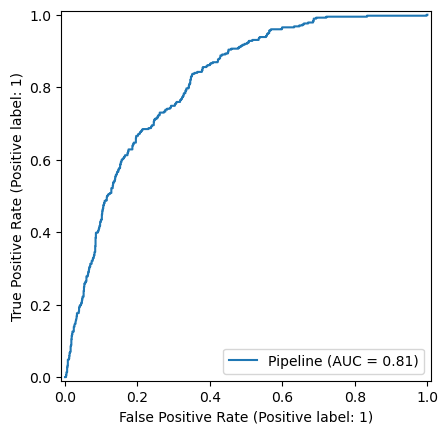

In [165]:
# fpr, tpr, thresholds = roc_curve(y_test, y_proba_opt)
# plt.plot([0, 1], [0, 1], 'k--' )
# plt.plot(fpr, tpr, label='Logistic Regression',color = "r")
# plt.xlabel('False Positive Rate')
# plt.ylabel('True Positive Rate')
# plt.title('Logistic Regression ROC Curve',fontsize=16)
# plt.show();

roc_logreg = RocCurveDisplay.from_estimator(best_model, X_test, y_test)
plt.show()

---

In [122]:
ohe = best_model.named_steps["preprocessing"].named_transformers_["cat"]
cat_features = ohe.get_feature_names_out(categorical_features)

feature_names = np.concatenate([
    numerical_features,
    cat_features
])
feature_names

array(['MonthlyCharges', 'ServiceScore', 'Contract_One year',
       'Contract_Two year', 'PaperlessBilling_Yes',
       'PaymentMethod_Credit card (automatic)',
       'PaymentMethod_Electronic check', 'PaymentMethod_Mailed check'],
      dtype=object)

In [123]:
coefficients = best_model.named_steps["model"].coef_[0]
coef_df = pd.DataFrame({
    "feature": feature_names,
    "coefficient": coefficients
})
coef_df = coef_df.loc[coef_df['coefficient'] != 0]
coef_df["odds_ratio"] = np.exp(coef_df["coefficient"])
coef_df = coef_df.sort_values(by='coefficient', ascending=False)
# coef_df.to_excel("coef.xlsx", index=False)
coef_df


,feature,coefficient,odds_ratio
6,PaymentMethod_Electronic check,0.713225,2.040562
0,MonthlyCharges,0.701220,2.016210
4,PaperlessBilling_Yes,0.387724,1.473623
7,PaymentMethod_Mailed check,0.256287,1.292124
5,PaymentMethod_Credit card (automatic),0.021197,1.021423
1,ServiceScore,-0.321751,0.724879
2,Contract_One year,-1.716318,0.179727
3,Contract_Two year,-2.939933,0.052869


In [124]:
best_model.named_steps['model'].coef_[0]

array([ 0.7012197 , -0.32175076, -1.71631841, -2.93993294,  0.38772383,
        0.0211968 ,  0.71322508,  0.25628709])

In [77]:
from sklearn.model_selection import StratifiedKFold

coefs = []

skf = StratifiedKFold(n_splits=5, random_state=42, shuffle=True)

for train_idx, test_idx in skf.split(X=X, y=y):
    best_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    coefs.append(best_model.named_steps['model'].coef_[0])

coef_matrix = pd.DataFrame(coefs, columns=feature_names)
coef_matrix = coef_matrix.T
coef_matrix['mean_abs'] = coef_matrix.apply(abs, axis=1).mean(axis=1)
coef_matrix['std'] = coef_matrix.drop(columns='mean_abs').apply(np.std, axis=1)
coef_matrix.sort_values(by='mean_abs', ascending=False)


,0,1,2,3,4,mean_abs,std
InternetService_Fiber optic,1.494743,1.615751,2.482513,1.458808,0.868869,1.584137,0.518341
Contract_Two year,-1.278964,-1.336643,-1.355646,-1.338152,-1.655776,1.393036,0.133892
MultipleLines_No phone service,-1.076148,-1.290542,-2.088245,-0.778685,-0.044244,1.055573,0.666558
PhoneService_Yes,-1.238226,-1.258319,-1.374547,-0.721139,-0.677932,1.054033,0.293482
OnlineBackup_No internet service,-1.336088,-0.822403,-2.238702,0.000000,0.047466,0.888932,0.859243
tenure,-0.847825,-0.854734,-0.834340,-0.841588,-0.802165,0.836130,0.018273
MonthlyCharges,-0.710287,-0.820291,-1.793098,-0.681079,0.109139,0.822779,0.605508
Contract_One year,-0.784718,-0.656001,-0.639837,-0.709083,-0.689064,0.695741,0.050683
StreamingMovies_Yes,0.620607,0.541581,0.887925,0.499884,0.183423,0.546684,0.226312
StreamingTV_Yes,0.507725,0.589977,0.832800,0.501401,0.178999,0.522180,0.209521


In [52]:
coef_matrix.loc[
	(coef_matrix['std'] <=0.3) &
	(coef_matrix['mean_abs'] >= 0.65)
].sort_values(by='mean_abs', ascending=False)

,0,1,2,3,4,mean_abs,std
Contract_Two year,-1.275190,-1.331877,-1.350560,-1.333495,-1.649459,1.388116,0.133123
tenure,-0.847597,-0.854617,-0.833701,-0.841479,-0.802327,0.835944,0.018167
PhoneService_Yes,-0.835256,-0.758258,-0.760285,-0.766543,-0.786969,0.781462,0.028753
Contract_One year,-0.783786,-0.655346,-0.639729,-0.708072,-0.687523,0.694891,0.050472


In [71]:
df_dataset.value_counts(subset=['InternetService', 'Churn'], normalize=True)

InternetService  Churn
DSL              0        0.278299
Fiber optic      0        0.255830
No               0        0.200085
Fiber optic      1        0.184443
DSL              1        0.065273
No               1        0.016069
Name: proportion, dtype: float64

In [72]:
# sns.boxplot(df_dataset, x='InternetService', y='MonthlyCharges', hue='Churn')

In [53]:
# from sklearn.model_selection import GridSearchCV, StratifiedKFold

param_grid = {
    "model__C": [0.01, 0.1, 1, 2, 3, 4, 5, 10, 100, 1000],
    "model__l1_ratio": [0, 1],
    "model__class_weight": [None, "balanced"],
	# "model__max_iter": [500, 1000, 1500, 2000],
    "model__solver": ["liblinear"]  # needed for l1
}

cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
grid_search = GridSearchCV(
    base_pipeline,
    param_grid,
    scoring="neg_log_loss",
    cv=cv,
    n_jobs=-1
)

grid_search.fit(X_train, y_train)


,"estimator estimator: estimator objectThis is assumed to implement the scikit-learn estimator interface.Either estimator needs to provide a ``score`` function,or ``scoring`` must be passed.",Pipeline(step..._iter=1000))])
,"param_grid param_grid: dict or list of dictionariesDictionary with parameters names (`str`) as keys and lists ofparameter settings to try as values, or a list of suchdictionaries, in which case the grids spanned by each dictionaryin the list are explored. This enables searching over any sequenceof parameter settings.","{'model__C': [0.01, 0.1, ...], 'model__class_weight': [None, 'balanced'], 'model__l1_ratio': [0, 1], 'model__solver': ['liblinear']}"
,"scoring scoring: str, callable, list, tuple or dict, default=NoneStrategy to evaluate the performance of the cross-validated model onthe test set.If `scoring` represents a single score, one can use:- a single string (see :ref:`scoring_string_names`);- a callable (see :ref:`scoring_callable`) that returns a single value;- `None`, the `estimator`'s :ref:`default evaluation criterion ` is used.If `scoring` represents multiple scores, one can use:- a list or tuple of unique strings;- a callable returning a dictionary where the keys are the metric names and the values are the metric scores;- a dictionary with metric names as keys and callables as values.See :ref:`multimetric_grid_search` for an example.",'neg_log_loss'
,"n_jobs n_jobs: int, default=NoneNumber of jobs to run in parallel.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary `for more details... versionchanged:: v0.20 `n_jobs` default changed from 1 to None",-1
,"refit refit: bool, str, or callable, default=TrueRefit an estimator using the best found parameters on the wholedataset.For multiple metric evaluation, this needs to be a `str` denoting thescorer that would be used to find the best parameters for refittingthe estimator at the end.Where there are considerations other than maximum score inchoosing a best estimator, ``refit`` can be set to a function whichreturns the selected ``best_index_`` given ``cv_results_``. In thatcase, the ``best_estimator_`` and ``best_params_`` will be setaccording to the returned ``best_index_`` while the ``best_score_``attribute will not be available.The refitted estimator is made available at the ``best_estimator_``attribute and permits using ``predict`` directly on this``GridSearchCV`` instance.Also for multiple metric evaluation, the attributes ``best_index_``,``best_score_`` and ``best_params_`` will only be available if``refit`` is set and all of them will be determined w.r.t this specificscorer.See ``scoring`` parameter to know more about multiple metricevaluation.See :ref:`sphx_glr_auto_examples_model_selection_plot_grid_search_digits.py`to see how to design a custom selection strategy using a callablevia `refit`.See :ref:`this example`for an example of how to use ``refit=callable`` to balance modelcomplexity and cross-validated score... versionchanged:: 0.20 Support for callable added.",True
,"cv cv: int, cross-validation generator or an iterable, default=NoneDetermines the cross-validation splitting strategy.Possible inputs for cv are:- None, to use the default 5-fold cross validation,- integer, to specify the number of folds in a `(Stratified)KFold`,- :term:`CV splitter`,- An iterable yielding (train, test) splits as arrays of indices.For integer/None inputs, if the estimator is a classifier and ``y`` iseither binary or multiclass, :class:`StratifiedKFold` is used. In allother cases, :class:`KFold` is used. These splitters are instantiatedwith `shuffle=False` so the splits will be the same across calls.Refer :ref:`User Guide ` for the variouscross-validation strategies that can be used here... versionchanged:: 0.22 ``cv`` default value if None changed from 3-fold to 5-fold.",StratifiedKFo... shuffle=True)
,"verbose verbose: intControls the verbosity: the higher, the more messages.- >1 : 

In [67]:
best_model = grid_search.best_estimator_

print("Best parameters:", grid_search.best_params_)


Best parameters: {'model__C': 100, 'model__class_weight': None, 'model__l1_ratio': 1, 'model__solver': 'liblinear'}


In [68]:
import numpy as np

thresholds = np.linspace(0.1, 0.5, 50)

best_f1 = 0
best_t = 0

for t in thresholds:
    y_pred_t = (y_proba >= t).astype(int)
    f1 = f1_score(y_test, y_pred_t)

    if f1 > best_f1:
        best_f1 = f1
        best_t = t

best_t, best_f1

(np.float64(0.3285714285714286), 0.6262857142857143)

In [69]:
y_proba = best_model.predict_proba(X_test)[:, 1]
# y_pred = base_pipeline.predict(X_test)
y_pred = (y_proba >= best_t).astype(int)

# print("Accuracy:", accuracy_score(y_test, y_pred))
# print("Precision:", precision_score(y_test, y_pred))
# print("Recall:", recall_score(y_test, y_pred))
# print("F1 Score:", f1_score(y_test, y_pred))
print("ROC AUC:", roc_auc_score(y_test, y_proba))
print("Log Loss:", log_loss(y_test, y_proba))

print("\nConfusion Matrix:\n", confusion_matrix(y_test, y_pred))
print("\nClassification Report:\n", classification_report(y_test, y_pred))


ROC AUC: 0.836982518079836
Log Loss: 0.424854880856097

Confusion Matrix:
 [[811 222]
 [101 273]]

Classification Report:
               precision    recall  f1-score   support

           0       0.89      0.79      0.83      1033
           1       0.55      0.73      0.63       374

    accuracy                           0.77      1407
   macro avg       0.72      0.76      0.73      1407
weighted avg       0.80      0.77      0.78      1407



In [74]:
coefs = []


for train_idx, test_idx in skf.split(X=X, y=y):
    best_model.fit(X.iloc[train_idx], y.iloc[train_idx])
    coefs.append(best_model.named_steps["model"].coef_[0])

coef_matrix = pd.DataFrame(coefs, columns=feature_names)
coef_matrix = coef_matrix.T
# coef_matrix = coef_matrix.describe().T.sort_values(by='mean', ascending=False)
# coef_matrix['mean']
coef_matrix['mean_abs'] = coef_matrix.apply(abs, axis=1).mean(axis=1)
coef_matrix['std'] = coef_matrix.drop(columns='mean_abs').apply(np.std, axis=1)
coef_matrix.sort_values(by='mean_abs', ascending=False)

,0,1,2,3,4,mean_abs,std
InternetService_Fiber optic,1.429052,1.615499,2.434301,1.463832,0.818765,1.552290,0.518268
Contract_Two year,-1.278913,-1.336638,-1.355452,-1.338104,-1.655830,1.392987,0.133937
PhoneService_Yes,-1.017093,-1.251778,-1.514176,-1.304488,-0.773258,1.172159,0.254556
MultipleLines_No phone service,-0.802789,-1.283748,-2.189697,-1.366058,-0.099619,1.148382,0.688387
tenure,-0.847773,-0.854756,-0.834255,-0.841597,-0.801966,0.836070,0.018347
DeviceProtection_No internet service,0.000000,-1.516084,-0.809668,-1.403875,-0.315494,0.809024,0.591925
MonthlyCharges,-0.631203,-0.820041,-1.735480,-0.687083,0.168981,0.808558,0.606344
Contract_One year,-0.784808,-0.656015,-0.639844,-0.709060,-0.689150,0.695775,0.050708
StreamingMovies_Yes,0.594596,0.541430,0.868608,0.501968,0.163297,0.533980,0.225449
StreamingTV_Yes,0.481569,0.589861,0.813787,0.503336,0.159001,0.509511,0.211053


In [61]:
coef_matrix.loc[
	(coef_matrix['std'] <=0.3) &
	(coef_matrix['mean_abs'] >= 0.65)
].sort_values(by='mean_abs', ascending=False)

,0,1,2,3,4,mean_abs,std
Contract_Two year,-1.278889,-1.336486,-1.355474,-1.338146,-1.655796,1.392958,0.133936
PhoneService_Yes,-1.352439,-1.220765,-1.553021,-1.323418,-0.899246,1.269778,0.214305
tenure,-0.847804,-0.854750,-0.834291,-0.841655,-0.802133,0.836126,0.018290
Contract_One year,-0.784752,-0.656035,-0.639854,-0.708918,-0.689130,0.695738,0.050676


---

In [81]:
df_logreg.groupby('Churn')['tenure'].describe().reset_index()

,Churn,count,mean,std,min,25%,50%,75%,max
0,0,5163.0,37.650010,24.076940,1.0,15.0,38.0,61.0,72.0
1,1,1869.0,17.979133,19.531123,1.0,2.0,10.0,29.0,72.0


In [87]:
df_logreg['tenure'].describe().reset_index()

,index,tenure
0,count,7032.000000
1,mean,32.421786
2,std,24.545260
3,min,1.000000
4,25%,9.000000
5,50%,29.000000
6,75%,55.000000
7,max,72.000000


<Axes: xlabel='tenure', ylabel='Count'>

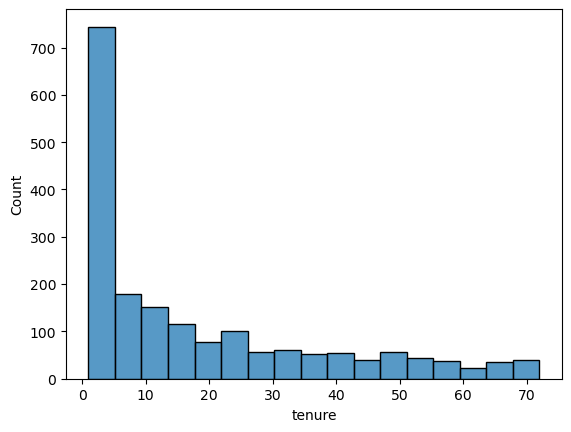

In [83]:
sns.histplot(df_logreg.loc[df_logreg['Churn'] == 1], x='tenure')

<Axes: ylabel='tenure'>

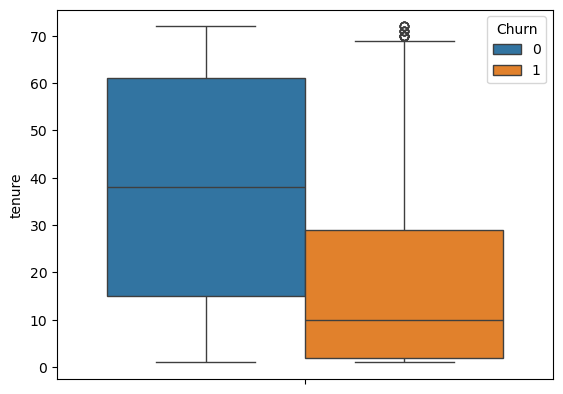

In [85]:
sns.boxplot(df_logreg, y='tenure', hue='Churn')

<Axes: xlabel='tenure', ylabel='Count'>

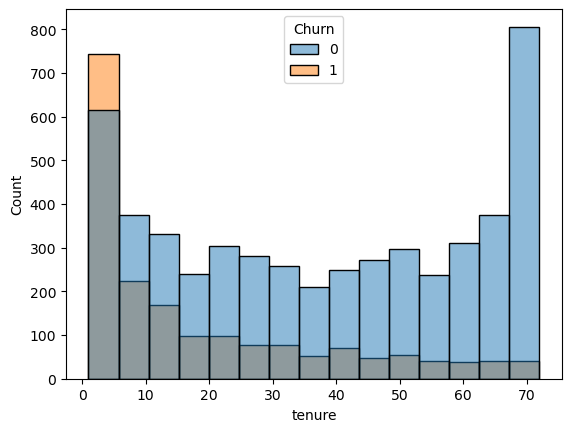

In [122]:
sns.histplot(df_logreg, x='tenure', hue='Churn')

In [90]:
def tenure_groups(value):
	if value < 3:
		return "0-3"
	elif 3<=value<=12:
		return "3-12"
	elif 12<=value<=24:
		return "12-24"
	else:
		return ">24"

In [92]:
df_logreg['tenure_group'] = df_logreg['tenure'].map(tenure_groups)
df_logreg['tenure_group'].value_counts()

tenure_group
>24      3833
3-12     1324
12-24    1024
0-3       851
Name: count, dtype: int64

In [117]:
df_logreg['Contract'].value_counts()

Contract
Month-to-month    3875
Two year          1685
One year          1472
Name: count, dtype: int64

In [118]:
def bill_renual(row):
	if row.get('Contract') == 'Month-to-month':
		return row['tenure']
	elif row.get('Contract') == 'One year':
		return round(row['tenure'] / 12, 2)
	elif row.get('Contract') == 'Two year':
		return round(row['tenure'] / 24, 2)

In [ ]:
df_logreg['bill_renewal'] = df_logreg.apply(bill_renual, axis=1)

In [28]:
df_logreg['bill_renewal'] 

KeyError: 'bill_renewal'